In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 连接数据库
con = sqlite3.connect('olist.db')

In [3]:
# =============================== 深入探究：用户支付情况 ==========================

# -------------- 数据准备 ----------------

# 提取支付与订单状态数据
payment_sql = """
SELECT 
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    p.payment_type,
    p.payment_installments,
    p.payment_value
FROM orders o
INNER JOIN order_payments p ON o.order_id = p.order_id
"""

df_payments = pd.read_sql_query(payment_sql, con)

# 处理重复值
df_payments.drop_duplicates(inplace=True)

# 转换时间格式
df_payments['order_purchase_timestamp'] = pd.to_datetime(df_payments['order_purchase_timestamp'])
df_payments['order_approved_at'] = pd.to_datetime(df_payments['order_approved_at'])

# 过滤 2016 年噪音数据
df_payments = df_payments[df_payments['order_purchase_timestamp'].dt.year != 2016]

# 计算 Boleto 支付确认延迟（小时）
# Boleto 需要银行清算，通常比信用卡慢
df_payments['pay_delay_hours'] = (df_payments['order_approved_at'] - df_payments['order_purchase_timestamp']).dt.total_seconds() / 3600

print("支付数据准备完毕！样本量：", len(df_payments))

支付数据准备完毕！样本量： 102927


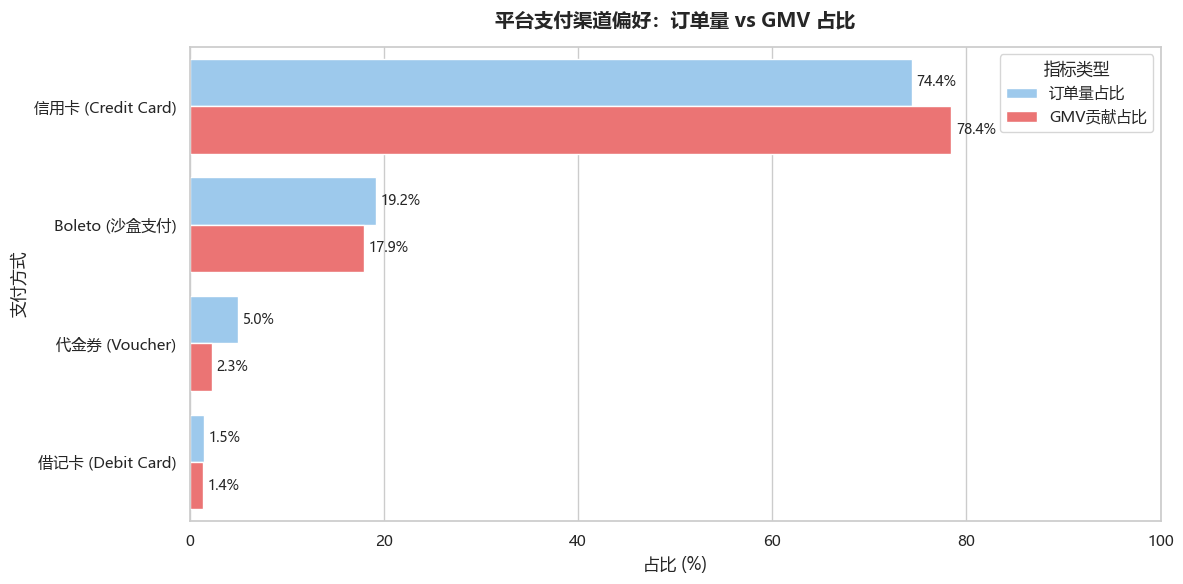

In [4]:
# --------------------------- 支付结构分析 ----------------------

# 计算支付方式占比
pay_summary = df_payments.groupby('payment_type').agg(
    order_count=('order_id', 'count'),
    total_gmv=('payment_value', 'sum')
).reset_index()

# 过滤掉极少数的 'not_defined'
pay_summary = pay_summary[pay_summary['payment_type'] != 'not_defined']

# 计算百分比
pay_summary['order_pct'] = pay_summary['order_count'] / pay_summary['order_count'].sum() * 100
pay_summary['gmv_pct'] = pay_summary['total_gmv'] / pay_summary['total_gmv'].sum() * 100
pay_summary = pay_summary.sort_values(by='gmv_pct', ascending=False)

# 映射中文名称
pay_map = {
    'credit_card': '信用卡 (Credit Card)',
    'boleto': 'Boleto (沙盒支付)',
    'voucher': '代金券 (Voucher)',
    'debit_card': '借记卡 (Debit Card)'
}
pay_summary['payment_type_zh'] = pay_summary['payment_type'].map(pay_map)

# 绘图
plt.figure(figsize=(12, 6))
plot_data = pd.melt(
    pay_summary, 
    id_vars=['payment_type_zh'], 
    value_vars=['order_pct', 'gmv_pct'],
    var_name='指标类型', 
    value_name='占比(%)'
)
plot_data['指标类型'] = plot_data['指标类型'].map({'order_pct': '订单量占比', 'gmv_pct': 'GMV贡献占比'})

ax = sns.barplot(
    x='占比(%)', 
    y='payment_type_zh', 
    hue='指标类型', 
    data=plot_data, 
    palette=['#90caf9', "#FF6060"]
)

# 标注数值
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', 
            va='center', 
            fontsize=10
        )

plt.title('平台支付渠道偏好：订单量 vs GMV 占比', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('占比 (%)')
plt.ylabel('支付方式')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# 从支付结构上看，信用卡是绝对的霸主，贡献了超过70%的订单量和交易额
# 但Boleto作为一种线下打印凭条，去商店或银行付款的传统方式，仍占据了近20%的市场份额
# 在互联网时代，巴西电商的生态仍带有明显的传统色彩，体现出新工具和新方式的普及过程中面对的环境阻力以及信任问题

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_39708\2497551482.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


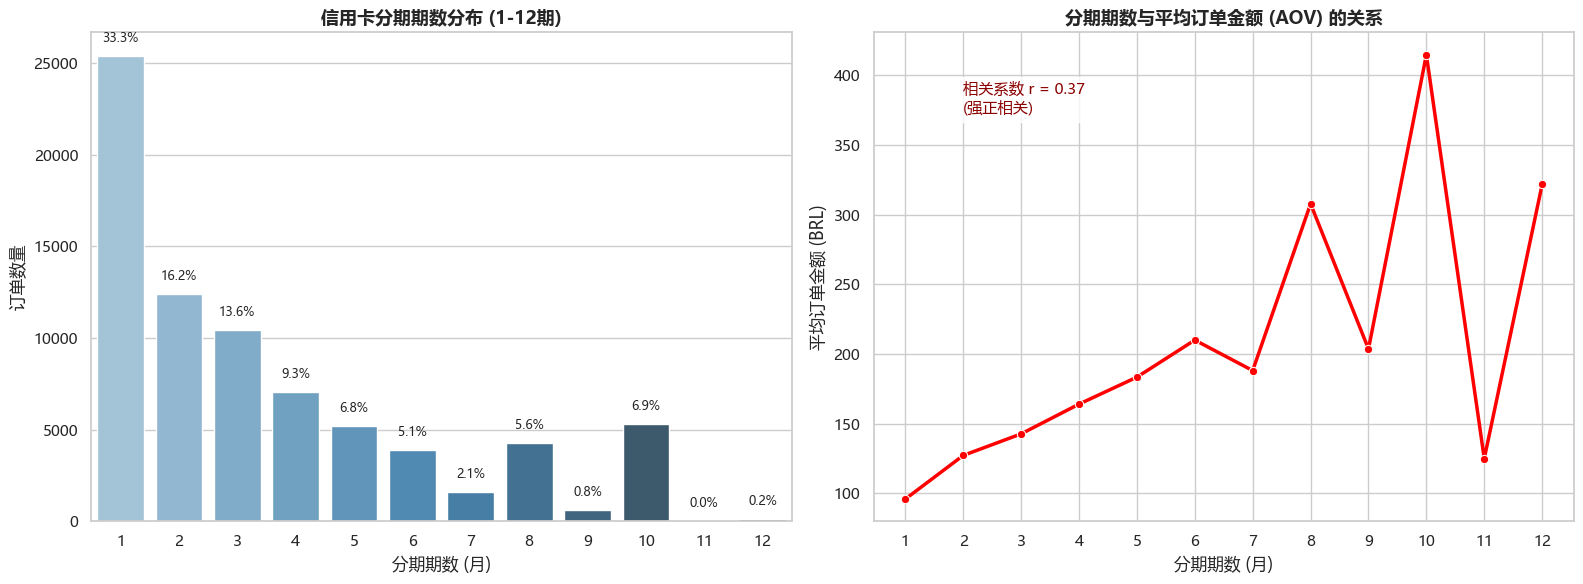

In [5]:
# ----------------------- 分期期数与客单价的关系 -------------------------------

# 过滤出信用卡数据
df_credit = df_payments[df_payments['payment_type'] == 'credit_card'].copy()

# 限制分期数在 1-12 期（排除极少数异常超长分期）
df_credit = df_credit[(df_credit['payment_installments'] >= 1) & (df_credit['payment_installments'] <= 12)]

# 计算各分期的平均订单金额
install_aov = df_credit.groupby('payment_installments')['payment_value'].mean().reset_index()

# 开始画双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 左图：分期期数分布
sns.countplot(
    x='payment_installments', 
    data=df_credit, 
    ax=ax1, 
    palette='Blues_d'
)
ax1.set_title('信用卡分期期数分布 (1-12期)', fontsize=13, fontweight='bold')
ax1.set_xlabel('分期期数 (月)')
ax1.set_ylabel('订单数量')

# 在柱状图上标百分比
total_credit_orders = len(df_credit)
for p in ax1.patches:
    height = p.get_height()
    pct = (height / total_credit_orders) * 100
    ax1.text(
        p.get_x() + p.get_width()/2, 
        height + total_credit_orders*0.01, 
        f'{pct:.1f}%', 
        ha='center', 
        fontsize=9
    )

# 2. 右图：分期期数 vs 平均订单金额 (AOV)
sns.lineplot(
    x='payment_installments', 
    y='payment_value', 
    data=install_aov, 
    ax=ax2, 
    marker='o', 
    color='red', 
    linewidth=2.5
)
ax2.set_title('分期期数与平均订单金额 (AOV) 的关系', fontsize=13, fontweight='bold')
ax2.set_xlabel('分期期数 (月)')
ax2.set_ylabel('平均订单金额 (BRL)')
ax2.set_xticks(range(1, 13))

# 计算相关系数
corr = df_credit['payment_installments'].corr(df_credit['payment_value'])
ax2.text(2, install_aov['payment_value'].max() * 0.9, f'相关系数 r = {corr:.2f}\n(强正相关)', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=11, color='darkred')

plt.tight_layout()
plt.show()


# 分期支付在巴西电商交易中非常普遍，只有三分之一的客户选择一期支付，并且分期期数与订单金额存在强正相关
# 说明就当下的经济环境下，分期支付将是平台的主流交易方式，有利于增加了客户的消费能力，增加了GMV和客单价
# 但是如此庞大的账单也具有极大的风险，大量的资金占用很考验平台的资金周转能力，以及需要科学健康的管理体系来避免坏账爆发的问题

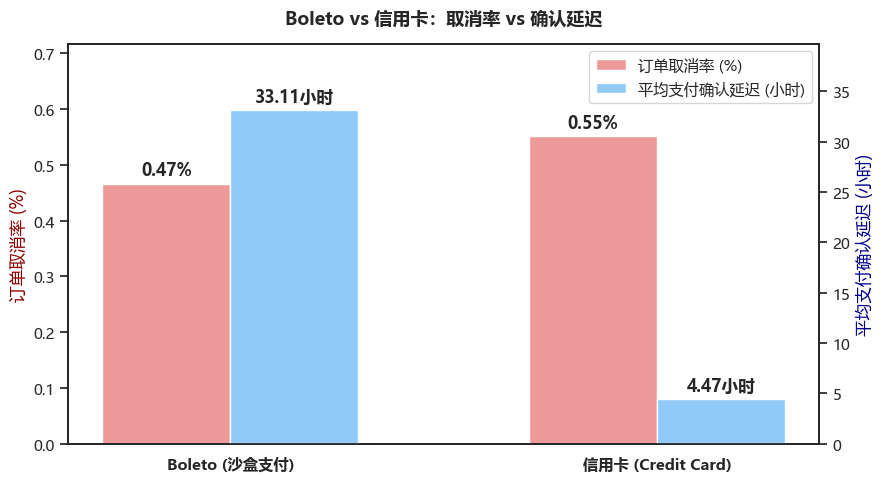

In [6]:
# Boleto与信用卡对比

# 计算取消率(%)和平均延迟
summary = df_payments[df_payments['payment_type'].isin(['credit_card', 'boleto'])].groupby('payment_type').agg(
    cancel_rate=('order_status', lambda x: (x == 'canceled').mean() * 100),
    avg_delay=('pay_delay_hours', 'mean')
).rename(index={'credit_card': '信用卡 (Credit Card)', 'boleto': 'Boleto (沙盒支付)'})

# ==============================================================================
# 2. 极简双 Y 轴画图
# ==============================================================================
sns.set_theme(style="white", rc={'font.sans-serif': ['Microsoft YaHei', 'SimHei'], 'axes.unicode_minus': False})
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = np.arange(len(summary))
width = 0.3

# 绘制双轴柱状图
rects1 = ax1.bar(x - width/2, summary['cancel_rate'], width, label='订单取消率 (%)', color='#ef9a9a')
rects2 = ax2.bar(x + width/2, summary['avg_delay'], width, label='平均支付确认延迟 (小时)', color='#90caf9')

ax1.bar_label(rects1, fmt='%.2f%%', padding=3, weight='bold')
ax2.bar_label(rects2, fmt='%.2f小时', padding=3, weight='bold')

# 轴与标签设置
ax1.set_xticks(x)
ax1.set_xticklabels(summary.index, fontsize=11, fontweight='bold')
ax1.set_ylabel('订单取消率 (%)', color='darkred')
ax2.set_ylabel('平均支付确认延迟 (小时)', color='darkblue')
ax1.set_ylim(0, summary['cancel_rate'].max() * 1.3)
ax2.set_ylim(0, summary['avg_delay'].max() * 1.2)

# 合并图例
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.title('Boleto vs 信用卡：取消率 vs 确认延迟', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# 由于需要用户线下去银行付款，Boleto的支付延迟确认时间远高于信用卡支付，但令人意想不到的是，Boleto的取消率却低于信用卡支付，仅有0.47%
# 作为一个综合性的电商平台，如此低的取消率除了能说明平台的运营成绩，还可能存在某些隐形问题，比如前面提到的极低的复购率，需要一定的警惕

In [7]:
# =============================== 商品与卖家生态 ============================

# --------------- 数据准备 ---------------

# 1. 提取品类与销售数据

con = sqlite3.connect('olist.db')

category_sql = """
SELECT 
    t.product_category_name_english AS category,
    oi.order_id,
    oi.price
FROM order_items oi
INNER JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
"""
df_cat_raw = pd.read_sql_query(category_sql, con)

# 2. 提取卖家服务质量数据
seller_sql = """
SELECT 
    oi.seller_id,
    oi.order_id,
    oi.price,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    r.review_score
FROM order_items oi
INNER JOIN orders o ON oi.order_id = o.order_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_carrier_date IS NOT NULL
"""
df_sel_raw = pd.read_sql_query(seller_sql, con)

# 转换时间格式
df_sel_raw['order_purchase_timestamp'] = pd.to_datetime(df_sel_raw['order_purchase_timestamp'])
df_sel_raw['order_delivered_carrier_date'] = pd.to_datetime(df_sel_raw['order_delivered_carrier_date'])

# 处理重复值
df_cat_raw.drop_duplicates(inplace=True)
df_cat_raw.drop_duplicates(inplace=True)

# 计算商家处理时长（天）
df_sel_raw['handling_days'] = (df_sel_raw['order_delivered_carrier_date'] - df_sel_raw['order_purchase_timestamp']).dt.total_seconds() / 86400

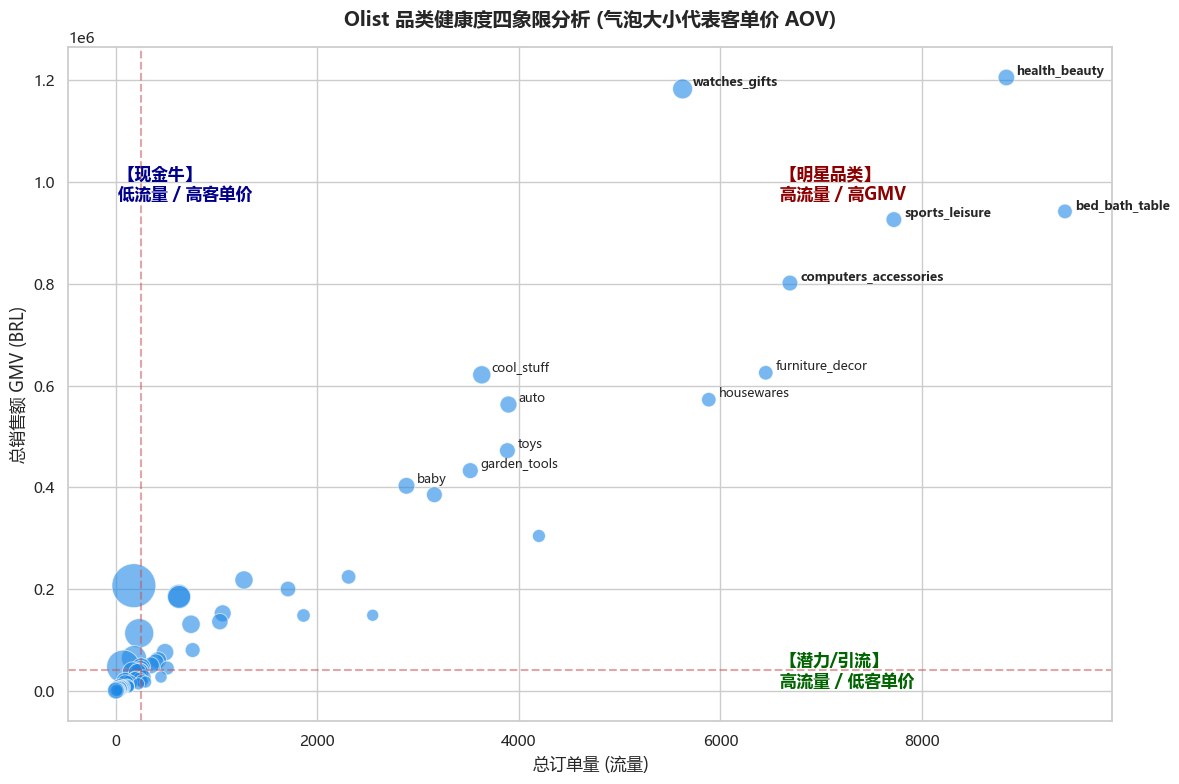

In [8]:
# ------------------ 品类分析 --------------------

# 聚合品类数据
df_cat = df_cat_raw.groupby('category').agg(
    order_volume=('order_id', 'nunique'),
    gmv=('price', 'sum')
).reset_index()
df_cat['aov'] = df_cat['gmv'] / df_cat['order_volume']

# 过滤掉无名品类
df_cat = df_cat.dropna().sort_values(by='gmv', ascending=False)

# 绘图设置
sns.set_theme(style="whitegrid", rc={'font.sans-serif': ['Microsoft YaHei', 'SimHei'], 'axes.unicode_minus': False})
plt.figure(figsize=(12, 8))

# 绘制散点图（气泡大小代表 AOV）
scatter = sns.scatterplot(
    x='order_volume', 
    y='gmv', 
    size='aov', 
    sizes=(50, 1000), 
    data=df_cat, 
    alpha=0.6, 
    color='#1e88e5',
    legend=False
)

# 划分象限（使用中位数划分，避免极值干扰）
x_median = df_cat['order_volume'].median()
y_median = df_cat['gmv'].median()

plt.axvline(x=x_median, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=y_median, color='r', linestyle='--', alpha=0.5)

# 标注 Top 10 热门品类名称
for i in range(min(12, len(df_cat))):
    row = df_cat.iloc[i]
    plt.text(
        row['order_volume'] + 100, 
        row['gmv'] + 5000, 
        row['category'], 
        fontsize=9, 
        weight='bold' if i < 5 else 'normal'
    )

# 象限文字标注
plt.text(df_cat['order_volume'].max()*0.7, df_cat['gmv'].max()*0.8, '【明星品类】\n高流量 / 高GMV', color='darkred', fontsize=12, weight='bold')
plt.text(x_median*0.1, df_cat['gmv'].max()*0.8, '【现金牛】\n低流量 / 高客单价', color='darkblue', fontsize=12, weight='bold')
plt.text(df_cat['order_volume'].max()*0.7, y_median*0.2, '【潜力/引流】\n高流量 / 低客单价', color='darkgreen', fontsize=12, weight='bold')

plt.title('Olist 品类健康度四象限分析 (气泡大小代表客单价 AOV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('总订单量 (流量)', fontsize=12)
plt.ylabel('总销售额 GMV (BRL)', fontsize=12)
plt.tight_layout()
plt.show()

# 从图可以看出，平台旗下有watch_gifts(手表礼品)、health_beauty(美妆)、computers_accessories(电脑配件)等多种主力产品，分散在多个领域里
# 平台可以进一步增加对现金牛类产品和卡在图中间的潜力产品的营销，削减一些边缘产品，促进产品销售的健康发展
# 针对主力产品的分散性，可能会面临来自垂直平台或具有招牌产品的其他平台的竞争压力
# 不能简单地摆上各种产品，作为综合性平台的同时，可以针对性深耕某些领域，增加消费者的信任感

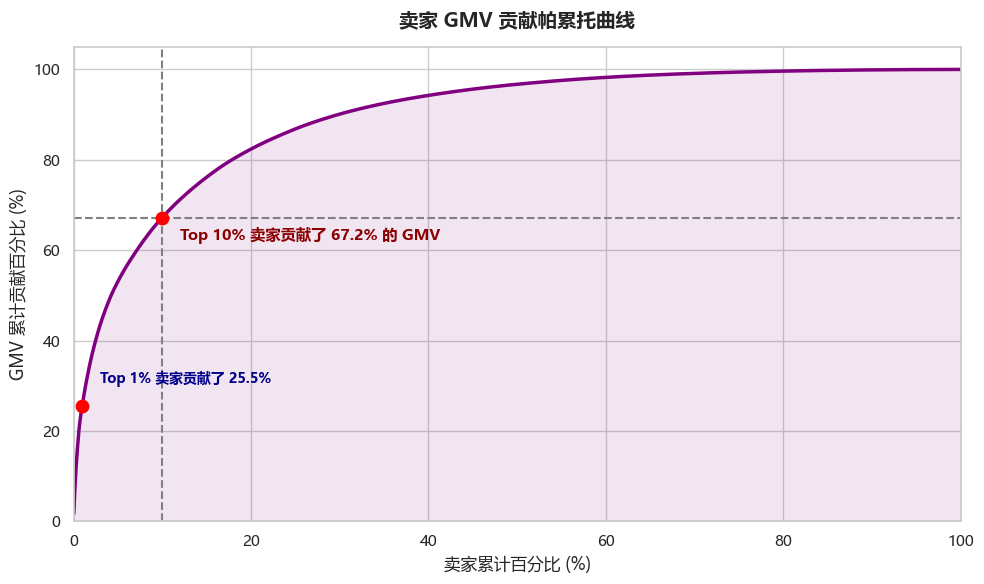

In [9]:
# ------------------------------- 卖家集中度分析 -------------------------

# 聚合卖家销售额
df_seller_sales = df_sel_raw.groupby('seller_id')['price'].sum().reset_index().sort_values(by='price', ascending=False)
df_seller_sales['cum_gmv'] = df_seller_sales['price'].cumsum()
df_seller_sales['cum_gmv_pct'] = (df_seller_sales['cum_gmv'] / df_seller_sales['price'].sum()) * 100

# 计算卖家累计百分比
df_seller_sales['seller_rank_pct'] = (np.arange(len(df_seller_sales)) + 1) / len(df_seller_sales) * 100

# 提取关键节点数据
top_1_pct = df_seller_sales[df_seller_sales['seller_rank_pct'] <= 1]['cum_gmv_pct'].max()
top_10_pct = df_seller_sales[df_seller_sales['seller_rank_pct'] <= 10]['cum_gmv_pct'].max()

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(df_seller_sales['seller_rank_pct'], df_seller_sales['cum_gmv_pct'], color='purple', linewidth=2.5, label='GMV 累计贡献率')
plt.fill_between(df_seller_sales['seller_rank_pct'], df_seller_sales['cum_gmv_pct'], color='purple', alpha=0.1)

# 标注关键点
plt.scatter([1, 10], [top_1_pct, top_10_pct], color='red', s=80, zorder=5)
plt.axvline(x=10, color='grey', linestyle='--')
plt.axhline(y=top_10_pct, color='grey', linestyle='--')

plt.text(12, top_10_pct - 5, f"Top 10% 卖家贡献了 {top_10_pct:.1f}% 的 GMV", color='darkred', weight='bold', fontsize=11)
plt.text(3, top_1_pct + 5, f"Top 1% 卖家贡献了 {top_1_pct:.1f}%", color='darkblue', weight='bold', fontsize=10)

plt.title('卖家 GMV 贡献帕累托曲线', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('卖家累计百分比 (%)', fontsize=12)
plt.ylabel('GMV 累计贡献百分比 (%)', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


# Olist平台也具有典型的八二法则，前10%的商家贡献了近70%的GMV

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_39708\2497737848.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='seller_group', y='avg_handling', data=group_comparison, ax=ax1, palette=['#ef9a9a', '#90caf9'])
C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_39708\2497737848.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='seller_group', y='avg_rating', data=group_comparison, ax=ax2, palette=['#ef9a9a', '#90caf9'])


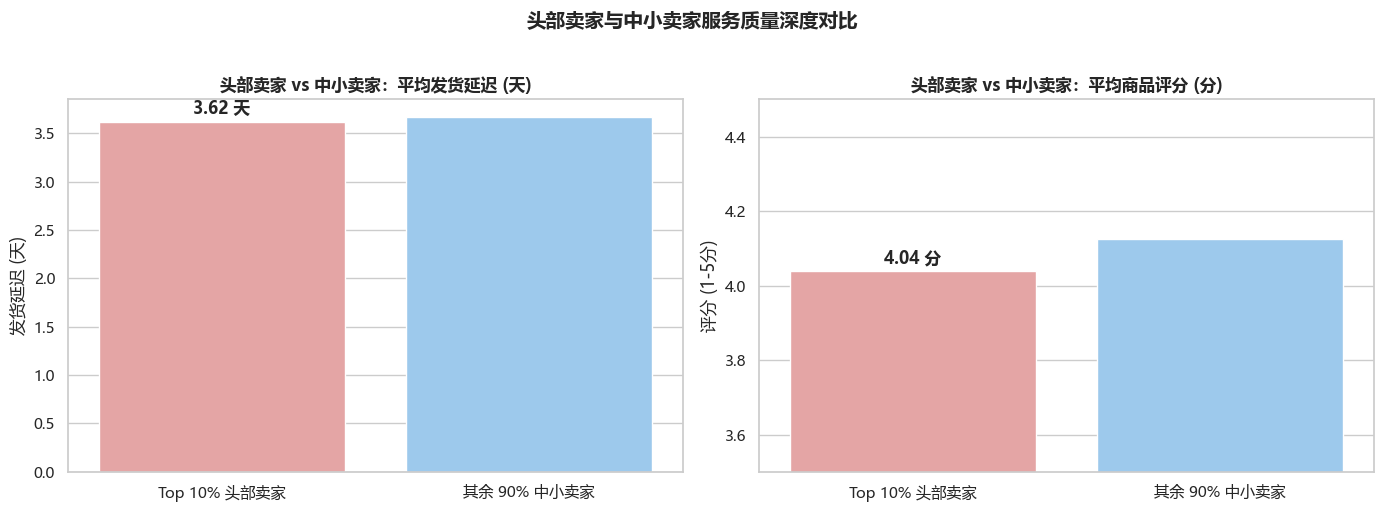

In [10]:
# -------------------- 卖家服务质量分析 --------------------

# 1. 计算每个卖家的销售额、平均评分、平均发货延迟
df_seller_metrics = df_sel_raw.groupby('seller_id').agg(
    total_sales=('price', 'sum'),
    avg_rating=('review_score', 'mean'),
    avg_handling=('handling_days', 'mean')
).reset_index()

# 2. 划分头部卖家（Top 10%）与普通卖家
threshold = df_seller_metrics['total_sales'].quantile(0.90)
df_seller_metrics['seller_group'] = np.where(df_seller_metrics['total_sales'] >= threshold, 'Top 10% 头部卖家', '其余 90% 中小卖家')

# 3. 聚合对比
group_comparison = df_seller_metrics.groupby('seller_group').agg(
    avg_rating=('avg_rating', 'mean'),
    avg_handling=('avg_handling', 'mean')
).reset_index()

# 4. 绘制对比图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：发货延迟对比
sns.barplot(x='seller_group', y='avg_handling', data=group_comparison, ax=ax1, palette=['#ef9a9a', '#90caf9'])
ax1.set_title('头部卖家 vs 中小卖家：平均发货延迟 (天)', fontsize=12, fontweight='bold')
ax1.set_ylabel('发货延迟 (天)')
ax1.set_xlabel('')
ax1.bar_label(ax1.containers[0], fmt='%.2f 天', padding=3, weight='bold')

# 右图：评分对比
sns.barplot(x='seller_group', y='avg_rating', data=group_comparison, ax=ax2, palette=['#ef9a9a', '#90caf9'])
ax2.set_title('头部卖家 vs 中小卖家：平均商品评分 (分)', fontsize=12, fontweight='bold')
ax2.set_ylabel('评分 (1-5分)')
ax2.set_xlabel('')
ax2.set_ylim(3.5, 4.5)  # 聚焦评分差异
ax2.bar_label(ax2.containers[0], fmt='%.2f 分', padding=3, weight='bold')

plt.suptitle('头部卖家与中小卖家服务质量深度对比', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 由图可知，头部卖家和中小卖家的平均发货延迟相差无几，可见物流问题是普遍存在
# 商品评分与商品质量、卖家服务、物流运输等多方面有关，是对商家综合评估的参考之一，值得注意的是头部卖家的平均商品评分低于中小卖家
# 头部卖家是平台支柱，平台需要加强对头部卖家的约束，帮助和督促头部卖家建立起更好的服务体系